In [84]:
from data_loader import DataLoader

In [85]:
data_loader = DataLoader("", "")

In [114]:
data = data_loader.fetch_historical_data('NEIROUSDT', '1h', '2022-12-31', '2025-05-19')
data.head()

,open,high,low,close,volume
timestamp,,,,,
2024-09-16 10:00:00,0.000031,0.000442,0.000031,0.000331,9.183450e+10
2024-09-16 11:00:00,0.000332,0.000369,0.000320,0.000333,3.722100e+10
2024-09-16 12:00:00,0.000333,0.000334,0.000306,0.000318,3.644107e+10
2024-09-16 13:00:00,0.000318,0.000386,0.000311,0.000383,7.163182e+10
2024-09-16 14:00:00,0.000383,0.000425,0.000368,0.000383,1.043681e+11


In [115]:
# data.to_csv('historical_sol_data_2023-25-05-18.csv')

In [116]:
data.index = data.index.tz_localize('UTC').tz_convert('Africa/Addis_Ababa').tz_localize(None)

In [117]:
data = data.iloc[21:-4]

In [118]:
data.tail()

,open,high,low,close,volume
timestamp,,,,,
2025-05-18 19:00:00,0.000628,0.000650,0.000616,0.000632,3.363141e+10
2025-05-18 20:00:00,0.000631,0.000638,0.000605,0.000611,2.009180e+10
2025-05-18 21:00:00,0.000611,0.000615,0.000585,0.000591,2.288665e+10
2025-05-18 22:00:00,0.000591,0.000605,0.000582,0.000588,1.630656e+10
2025-05-18 23:00:00,0.000588,0.000593,0.000570,0.000582,1.735224e+10


### Entropy

In [119]:
from __future__ import annotations

import argparse
from datetime import datetime, timedelta
from typing import Iterable, List, Literal, Tuple, Dict

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from pandas.tseries.frequencies import to_offset
from scipy.stats import entropy

In [120]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [121]:
# data = pd.read_csv('historical_neiro_data_2023-25-05-16.csv', index_col=0, parse_dates=True)
# data.index = data.index.tz_localize('UTC').tz_convert('Africa/Addis_Ababa').tz_localize(None)
# data.head()

In [122]:

###############################################################################
# 2 ─── Return Labelling                                                       ──
###############################################################################

def _fixed_bins() -> List[float]:
    """Default symmetric ±0.5%, ±2%, ±5% boundaries."""
    return [-np.inf, -0.05, -0.02, -0.005, 0.005, 0.02, 0.05, np.inf]


def _vol_scaled_bins(returns: pd.Series, mults: Iterable[float] = (-3, -2, -1, 1, 2, 3)) -> List[float]:
    sig = returns.std(ddof=0)
    if np.isnan(sig) or sig == 0:
        raise ValueError("Volatility is zero – cannot build vol‑scaled bins.")
    edges = [-np.inf] + [m * sig for m in mults] + [np.inf]
    # ensure monotonic
    return sorted(edges)


def _quantile_bins(returns: pd.Series, quantiles: Iterable[float] = (0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99)) -> List[float]:
    qs = returns.quantile(list(quantiles)).to_list()
    return [-np.inf] + qs + [np.inf]


def choose_magnitude_bins(
    returns: pd.Series,
    scheme: Literal["fixed", "vol", "quantile"] = "fixed",
    *,
    mults: Iterable[float] | None = None,
    quantiles: Iterable[float] | None = None,
) -> List[float]:
    """Return a list of bin edges according to desired scheme."""
    if scheme == "fixed":
        return _fixed_bins()
    elif scheme == "vol":
        return _vol_scaled_bins(returns, mults or (-3, -2, -1, 1, 2, 3))
    elif scheme == "quantile":
        return _quantile_bins(returns, quantiles or (0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99))
    else:
        raise ValueError(f"Unknown bin scheme: {scheme}")


def label_returns(
    closes: pd.Series,
    scheme: Literal["fixed", "vol", "quantile"] = "fixed",
    lookback: int | None = None,
    **kwargs,
) -> Tuple[pd.Series, List[float]]:
    """Compute log returns and bucket them.

    Parameters
    ----------
    closes : Series of prices indexed by date‑time.
    scheme : str, default "fixed"
        Bin construction method.
    lookback : int, optional
        Number of most‑recent observations to use for bin calibration; None = all.

    Returns
    -------
    labels : Series of categorical integers (0 … k‑1) aligned with *closes*.
    bin_edges : list[float] for reproducibility/documentation.
    """
    log_ret = np.log(closes).diff()
    calib_slice = log_ret.dropna() if lookback is None else log_ret.dropna().iloc[-lookback:]
    edges = choose_magnitude_bins(calib_slice, scheme, **kwargs)
    labels = pd.cut(log_ret, bins=edges, labels=False, right=False)
    return labels, edges

###############################################################################
# 3 ─── Bucket Keys (calendar partitions)                                       ──
###############################################################################

def calendar_bucket(
    index: pd.DatetimeIndex,
    level: Literal["week", "weekday", "hour", "4h", "session"] = "weekday",
) -> pd.Index:
    """Return a key per timestamp describing the requested temporal bucket."""
    if level == "week":
        return index.isocalendar().week.astype(int)
    if level == "weekday":
        return index.weekday
    if level == "hour":
        return index.hour  # 0‑23
    if level == "4h":
        return (index.hour // 4)  # 0‑5 representing 6 × 4‑hour blocks
    if level == "session":
        # Crypto pseudo‑sessions
        h = index.hour
        labels = np.select(
            [
                (h >= 0) & (h < 7),      # Asia early-mid
                (h >= 7) & (h < 13),     # Europe
                (h >= 13) & (h < 20),    # US
                (h >= 20) & (h < 24),    # Asia late / Pacific
            ],
            ["AS", "EU", "US", "AS"],
            default="AS",
        )
        return pd.Series(labels, index=index)
    raise ValueError(level)

###############################################################################
# 4 ─── PMF, Entropy, Mutual Information                                       ─
###############################################################################

def pmf(df: pd.DataFrame, bucket_col: str, label_col: str) -> pd.DataFrame:
    counts = df.groupby(bucket_col)[label_col].value_counts().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)


def entropy_bits(probs: pd.Series) -> float:
    return entropy(probs, base=2)


def bucket_entropy(pmf_df: pd.DataFrame) -> pd.Series:
    return pmf_df.apply(entropy_bits, axis=1)


def mutual_information(global_probs: pd.Series, cond_pmf: pd.DataFrame) -> pd.Series:
    H_global = entropy_bits(global_probs)
    H_cond = cond_pmf.apply(entropy_bits, axis=1)
    return H_global - H_cond  # in bits

###############################################################################
# 5 ─── Rolling Engine                                                      ─
###############################################################################

def rolling_entropy(
    df: pd.DataFrame,
    *,
    bucket_level: str = "weekday",
    window_days: int = 90,
    label_scheme: str = "fixed",
    stride_days: int = 1,
    **label_kwargs,
) -> pd.DataFrame:
    closes = df["close"].copy()
    out: Dict[pd.Timestamp, pd.Series] = {}
    dates = closes.index.normalize().unique()[window_days::stride_days]
    for as_of in dates:
        sub = closes.loc[as_of - pd.Timedelta(days=window_days): as_of]
        lbl, _edges = label_returns(sub, scheme=label_scheme, **label_kwargs)
        joined = pd.DataFrame({"label": lbl, "bucket": calendar_bucket(lbl.index, bucket_level)})
        probs = pmf(joined.dropna(), "bucket", "label")
        out[as_of] = bucket_entropy(probs)
    return pd.DataFrame(out).T


In [123]:
###############################################################################
# 6 ─── Demo / CLI                                                              ─
###############################################################################

# def demo(raw: pd.DataFrame) -> pd.DataFrame:
#     return rolling_entropy(raw, bucket_level="weekday", window_days=90, label_scheme="fixed").tail()


# def build_argparser():
#     ap = argparse.ArgumentParser(description="BTC Entropy Workbench")
#     ap.add_argument("--start", type=str, help="YYYY‑MM‑DD", default=(datetime.utcnow() - timedelta(days=365*2)).strftime("%Y-%m-%d"))
#     ap.add_argument("--end", type=str, help="YYYY‑MM‑DD", default=datetime.utcnow().strftime("%Y-%m-%d"))
#     ap.add_argument("--interval", type=str, default="1h", help="yfinance interval (1h, 2h, 1d…)")
#     ap.add_argument("--bucket", type=str, choices=["week","weekday","hour","4h","session"], default="weekday")
#     ap.add_argument("--window", type=int, default=90, help="rolling window size in days")
#     ap.add_argument("--label", type=str, choices=["fixed","vol","quantile"], default="fixed")
#     return ap


# def main():
#     args = build_argparser().parse_args()
#     raw = get_btc_prices(args.start, args.end, args.interval)
#     ent = rolling_entropy(raw, bucket_level=args.bucket, window_days=args.window, label_scheme=args.label)
#     print(ent.tail())

In [124]:
# demo(data)

In [125]:
###############################################################################
# 6 ─── Collector (Entropy + PMF + Edges)                                   ─
###############################################################################

def rolling_entropy_full(
    df: pd.DataFrame,
    *,
    bucket_level: str = "weekday",
    window_days: int = 90,
    label_scheme: str = "fixed",
    stride_days: int = 1,
    **label_kwargs,
):
    closes = df["close"].copy()
    ent_out: Dict[pd.Timestamp, pd.Series] = {}
    pmf_out: Dict[pd.Timestamp, pd.DataFrame] = {}
    edges_out: Dict[pd.Timestamp, List[float]] = {}
    dates = closes.index.normalize().unique()[window_days::stride_days]
    for as_of in dates:
        sub = closes.loc[as_of - pd.Timedelta(days=window_days): as_of]
        lbl, edges = label_returns(sub, scheme=label_scheme, **label_kwargs)
        joined = pd.DataFrame({"label": lbl, "bucket": calendar_bucket(lbl.index, bucket_level)})
        probs = pmf(joined.dropna(), "bucket", "label")
        ent_out[as_of] = bucket_entropy(probs)
        pmf_out[as_of] = probs
        edges_out[as_of] = edges
    ent_df = pd.DataFrame(ent_out).T
    return ent_df, pmf_out, edges_out

###############################################################################
# 7 ─── Quick‑Plot Helper                                                     ─
###############################################################################

def plot_pmf_heatmap(pmf_df: pd.DataFrame, *, ax: plt.Axes | None = None, title: str | None = None):
    """Visualise a bucket × magnitude PMF as a simple heat‑map (matplotlib only).

    Parameters
    ----------
    pmf_df : DataFrame
        Rows = bucket IDs, Columns = magnitude labels, values = probability.
    ax : matplotlib Axes, optional
    title : str, optional
        Figure title.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(pmf_df.values, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(pmf_df.columns)))
    ax.set_xticklabels(pmf_df.columns, rotation=90)
    ax.set_yticks(range(len(pmf_df.index)))
    ax.set_yticklabels(pmf_df.index)
    if title:
        ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Probability", rotation=-90, va="bottom")
    return ax

In [126]:
# Pretty‑print demo
def demo_pretty(raw: pd.DataFrame, *, bucket_level: str = "weekday", window_days: int = 90, label_scheme: str = "fixed", **label_kwargs):
    ent, pmfs, edges_dict = rolling_entropy_full(raw, bucket_level=bucket_level, window_days=window_days, label_scheme=label_scheme, **label_kwargs)
    last = ent.index[-1]
    edges = edges_dict[last]
    print("\nBin ↔ English mapping\n---------------------")
    display(bin_mapping_table(edges))
    print("\nEntropy (bits/certainty) — last five windows\n----------------------------------")
    display(pretty_entropy(ent.tail(), edges, bucket_level))
    print(f"\nPMF (Probability) for window ending {last.date()}\n----------------------------------")
    display(pretty_pmf(pmfs[last], edges, bucket_level))

###############################################################################
# 8 ─── Pretty‑Print Helpers                                                ─
###############################################################################

weekday_abbr = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}

# ‑‑‑‑‑ bucket label formatter

def _bucket_label(val, level: str) -> str:
    if level == "weekday":
        return weekday_abbr.get(int(val), str(val))
    if level == "hour":
        return f"{int(val):02d}:00"
    if level == "4h":
        start = int(val) * 4
        end = start + 4
        return f"{start:02d}-{end:02d}"
    if level == "week":
        return f"W{int(val):02d}"
    # session already textual
    return str(val)

def _bin_names(edges_or_indices):
    """Map bin indices or edge positions to plain-English descriptions."""
    name_map = {
        0: "huge loss",
        1: "medium loss",
        2: "small loss",
        3: "flat",
        4: "small gain",
        5: "medium gain",
        6: "huge gain"
    }
    return [name_map.get(i, str(i)) for i in edges_or_indices]

# ‑‑‑‑‑ magnitude label formatter

def _plain_english(lo: float, hi: float) -> str:
    # fallbacks for ±inf boundaries
    if math.isinf(lo) and math.isinf(hi):
        return "unknown"
    # choose human category from range midpoint
    mid = (lo + hi) / 2 if not math.isinf(lo) and not math.isinf(hi) else lo if not math.isinf(lo) else hi
    if mid <= -0.05:
        return "huge loss"
    if mid <= -0.02:
        return "medium loss"
    if mid <= -0.005:
        return "small loss"
    if mid < 0.005:
        return "flat"
    if mid < 0.02:
        return "small gain"
    if mid < 0.05:
        return "medium gain"
    return "huge gain"


def _col_names(edges: List[float]) -> List[str]:
    return [_plain_english(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

# ‑‑‑‑‑ mapping table for documentation

def bin_mapping_table(edges: List[float]) -> pd.DataFrame:
    names = _col_names(edges)
    rows = []
    for i, (lo, hi, nm) in enumerate(zip(edges[:-1], edges[1:], names)):
        rows.append({"id": i, "interval": f"[{lo:.3f}, {hi:.3f})" if not math.isinf(lo) and not math.isinf(hi) else f"{('-∞' if lo == -np.inf else f'{lo:.3f}')}, {('∞' if hi == np.inf else f'{hi:.3f}')}", "english": nm})
    return pd.DataFrame(rows).set_index("id")

# ‑‑‑‑‑ PMF pretty

def pretty_pmf(p: pd.DataFrame, edges: List[float], bucket_level: str) -> pd.DataFrame:
    df = p.copy()
    df.index = [_bucket_label(b, bucket_level) for b in df.index]
    df.columns = _col_names(edges)[: df.shape[1]]  # align in case trailing labels absent
    return (df * 100).round(1).astype(str) + " %"

# ‑‑‑‑‑ Entropy pretty

def pretty_entropy(ent: pd.DataFrame, edges: List[float], bucket_level: str) -> pd.DataFrame:
    k = len(edges) - 1
    maxH = math.log2(k)
    df = ent.copy()
    df.columns = [_bucket_label(c, bucket_level) for c in df.columns]
    def fmt(x: float) -> str:
        pred = 1 - x / maxH
        return f"{x:.3f} ({pred:.0%})"
    return df.map(fmt)

In [127]:
def demo_pretty_consolidated(
    raw: pd.DataFrame,
    *,
    bucket_level: str = "weekday",
    window_days: int = 90,
    label_scheme: str = "fixed",
    **label_kwargs,
):
    """One‑table presentation: PMF with interval‑aware columns and predictability hints.

    ‑ Adds interval ranges to each magnitude column label.
    ‑ Adds mean‑of‑last‑5‑windows predictability (M) and actual current predictability (A)
      inside each bucket index.
    """
    ent, pmfs, edges_dict = rolling_entropy_full(
        raw,
        bucket_level=bucket_level,
        window_days=window_days,
        label_scheme=label_scheme,
        **label_kwargs,
    )

    # ------- utilities -----------------------------------------------------
    def col_labels(edges: list[str | float]):
        names = _col_names(edges)
        rng = []
        for lo, hi in zip(edges[:-1], edges[1:]):
            lo_s = "‑∞" if lo == -np.inf else f"{lo*100:.1f}%"
            hi_s = "∞" if hi == np.inf else f"{hi*100:.1f}%"
            rng.append(f"[{lo_s}, {hi_s})")
        return [f"{n} {r}" for n, r in zip(names, rng)]

    def predictability_bits(h: float, k: int) -> float:
        return 1 - h / math.log2(k)

    # ------- choose last window & stats -----------------------------------
    last = ent.index[-1]
    edges = edges_dict[last]
    k = len(edges) - 1

    # compute mean predictability over last 5 windows per bucket
    ent_last5 = ent.tail(5)
    pred_mean = ent_last5.map(lambda x: predictability_bits(x, k)).mean()
    pred_curr = ent_last5.tail(1).map(lambda x: predictability_bits(x, k)).iloc[0]

    # build PMF pretty table
    pmf_last = pmfs[last].copy()
    pmf_last.columns = col_labels(edges)[: pmf_last.shape[1]]
    pretty = (pmf_last * 100).round(1).astype(str) + "%"

    # inject index labels with predictability
    new_idx = []
    for b in pretty.index:
        label = _bucket_label(b, bucket_level)
        m = pred_mean.get(b, np.nan) * 100
        a = pred_curr.get(b, np.nan) * 100
        new_idx.append(f"{label} ({m:.0f}%M ‑ {a:.0f}%A)")
    pretty.index = new_idx

    # ------- print ---------------------------------------------------------
    title = f"PMF + Predictability | bucket={bucket_level} | window={window_days}d | scheme={label_scheme} | as of {last.date()}"
    print("" + title + "\n" + "‑" * len(title))
    display(pretty)

"week", "weekday", "hour", "4h", "session"

"fixed", "vol", "quantile"

In [128]:
demo_pretty_consolidated(data, bucket_level="weekday", window_days=30, label_scheme="fixed")

PMF + Predictability | bucket=weekday | window=30d | scheme=fixed | as of 2025-05-18
‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑


,"huge loss [‑∞, -5.0%)","medium loss [-5.0%, -2.0%)","small loss [-2.0%, -0.5%)","flat [-0.5%, 0.5%)","small gain [0.5%, 2.0%)","medium gain [2.0%, 5.0%)","huge gain [5.0%, ∞)"
Mon (28%M ‑ 27%A),0.0%,8.3%,30.2%,19.8%,36.5%,5.2%,0.0%
Tue (17%M ‑ 16%A),2.1%,4.2%,27.1%,22.9%,29.2%,9.4%,5.2%
Wed (17%M ‑ 15%A),3.1%,11.5%,28.1%,20.8%,21.9%,14.6%,0.0%
Thu (15%M ‑ 10%A),3.1%,9.4%,18.8%,25.0%,27.1%,11.5%,5.2%
Fri (18%M ‑ 18%A),0.0%,9.2%,27.7%,29.4%,19.3%,11.8%,2.5%
Sat (12%M ‑ 11%A),2.5%,11.7%,27.5%,27.5%,15.0%,10.0%,5.8%
Sun (21%M ‑ 21%A),2.1%,5.2%,28.9%,29.9%,23.7%,10.3%,0.0%


In [129]:
demo_pretty_consolidated(data, bucket_level="4h", window_days=30, label_scheme="fixed")

PMF + Predictability | bucket=4h | window=30d | scheme=fixed | as of 2025-05-18
‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑


,"huge loss [‑∞, -5.0%)","medium loss [-5.0%, -2.0%)","small loss [-2.0%, -0.5%)","flat [-0.5%, 0.5%)","small gain [0.5%, 2.0%)","medium gain [2.0%, 5.0%)","huge gain [5.0%, ∞)"
00-04 (15%M ‑ 14%A),2.5%,8.3%,25.0%,23.3%,25.0%,14.2%,1.7%
04-08 (16%M ‑ 15%A),2.5%,10.8%,21.7%,29.2%,25.8%,8.3%,1.7%
08-12 (17%M ‑ 14%A),1.7%,8.3%,30.8%,21.7%,22.5%,10.8%,4.2%
12-16 (17%M ‑ 14%A),1.7%,10.0%,26.7%,23.3%,25.0%,10.8%,2.5%
16-20 (12%M ‑ 11%A),1.7%,10.8%,29.2%,22.5%,17.5%,12.5%,5.8%
20-24 (26%M ‑ 26%A),0.8%,3.3%,28.3%,31.7%,29.2%,5.8%,0.8%


In [130]:
demo_pretty_consolidated(data, bucket_level="hour", window_days=30, label_scheme="fixed")

PMF + Predictability | bucket=hour | window=30d | scheme=fixed | as of 2025-05-18
‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑


,"huge loss [‑∞, -5.0%)","medium loss [-5.0%, -2.0%)","small loss [-2.0%, -0.5%)","flat [-0.5%, 0.5%)","small gain [0.5%, 2.0%)","medium gain [2.0%, 5.0%)","huge gain [5.0%, ∞)"
00:00 (19%M ‑ 18%A),3.3%,3.3%,36.7%,20.0%,23.3%,10.0%,3.3%
01:00 (20%M ‑ 16%A),3.3%,13.3%,23.3%,26.7%,23.3%,10.0%,0.0%
02:00 (26%M ‑ 27%A),0.0%,6.7%,6.7%,33.3%,33.3%,20.0%,0.0%
03:00 (11%M ‑ 12%A),3.3%,10.0%,33.3%,13.3%,20.0%,16.7%,3.3%
04:00 (14%M ‑ 14%A),6.7%,13.3%,23.3%,36.7%,10.0%,6.7%,3.3%
05:00 (19%M ‑ 20%A),0.0%,10.0%,26.7%,20.0%,33.3%,6.7%,3.3%
06:00 (24%M ‑ 22%A),3.3%,13.3%,6.7%,36.7%,30.0%,10.0%,0.0%
07:00 (25%M ‑ 24%A),0.0%,6.7%,30.0%,23.3%,30.0%,10.0%,0.0%
08:00 (19%M ‑ 16%A),0.0%,10.0%,16.7%,30.0%,23.3%,16.7%,3.3%
09:00 (24%M ‑ 22%A),3.3%,3.3%,36.7%,26.7%,16.7%,13.3%,0.0%


In [131]:
demo_pretty_consolidated(data, bucket_level="session", window_days=30, label_scheme="fixed")

PMF + Predictability | bucket=session | window=30d | scheme=fixed | as of 2025-05-18
‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑


,"huge loss [‑∞, -5.0%)","medium loss [-5.0%, -2.0%)","small loss [-2.0%, -0.5%)","flat [-0.5%, 0.5%)","small gain [0.5%, 2.0%)","medium gain [2.0%, 5.0%)","huge gain [5.0%, ∞)"
AS (18%M ‑ 17%A),2.1%,7.6%,24.5%,28.5%,26.4%,9.4%,1.5%
EU (18%M ‑ 15%A),1.1%,7.8%,30.6%,20.6%,24.4%,12.2%,3.3%
US (13%M ‑ 12%A),1.9%,11.0%,27.6%,24.3%,20.5%,10.5%,4.3%


### 📋 Prompt template

 **Prompt – Deep-Dive on BTC PMF & Predictability**
 **Table provided:**

 ```
 <paste the “PMF + Predictability” table here>
 ```
Please analyse this table and deliver a concise yet comprehensive insight report.
Cover **every** point below; use headings & bullet points where appropriate and quote exact numbers (with %).
1. **Most Predictable Buckets**
   * Rank the buckets by **actual predictability (A)**; highlight any ≥ 25 %.
   * Comment on how the **five-window mean (M)** compares—are things becoming more or less orderly?
2. **Directional Skews**
   * For each bucket, identify the **dominant outcome label** (> 30 % probability) and the strongest *counter-outcome*.
   * Flag buckets where gains dominate losses or vice-versa by ≥ 15 pp.
3. **Mean-Reversion vs Trend Signals**
   * Using the “flat” row and the two adjacent bins (small loss, small gain), state whether the slice tilts toward **mean reversion** or **momentum**.
   * Give at least one concrete trade idea (e.g., “Fade small gains on Monday if P(small loss) > P(small gain) by 10 pp”).
4. **Tail-Risk Hotspots**
   * Note any bucket where **huge loss or huge gain** frequency ≥ 5 %.
   * Explain what time it occurs and how that could affect position sizing or stop-loss placement.
5. **Drift Detection (M vs A)**
   * For each bucket, compute **Δ = A − M**; list the top 2 buckets by absolute drift.
   * State whether the drift reflects **new opportunity** or **model decay**.
6. **Cross-Bucket Themes**
   * Compare weekday vs weekend, or session blocks, depending on the table.
   * Summarise any obvious seasonality (e.g., “Asia-late 20-24 block shows the highest gains but lowest predictability”).
7. **Priority Action List**
   * End with 3–5 bullet-point recommendations (trading, monitoring, or further research).
   * Each recommendation should reference a specific number from the table.

### 🗂 Mini-Example (use as a guide)

*Assume the row for “Fri (18 % M – 18 %A)” shows 47 % small-loss, 29 % flat, 20 % small-gain.*

* **Most Predictable:** Saturday tops at 12 %A (but still low); 20 %+ predictability absent → market relatively noisy overall.
* **Directional Skew:** Friday’s “small-loss” at 47 % vs “small-gain” 20 % → **bearish bias** of 27 pp.
* **Mean-Reversion:** “Small gain” flips to “small loss” more often than it persists → fade rallies on Fridays.
* **Tail-Risk:** No bucket breaches 5 % huge-loss/gain, so tail hedges can stay light.
* **Drift:** Tue dropped from 23 % M to 16 %A (−7 pp) → predictability deteriorating → reduce weight on Tuesday edges.
* **Action:**

  1. Short intra-day pops on Friday; stop if small-gain frequency > 25 %.
  2. Re-evaluate Tuesday strategies—edge eroding.
  3. Keep risk flat on weekend; edges weak and volatile.


In [132]:
###############################################################################
# 9 ─── Rolling Markov Chain Analysis                                         ─
###############################################################################

def markov_chain_metrics(
    label_series: pd.Series,
    bin_edges: list,
    up_bins=None,
    down_bins=None,
    prev_matrix=None
):
    k = len(bin_edges) - 1  # number of bins = number of states
    all_states = list(range(k))

    # Default up/down bins based on 7-label layout, but will clip if fewer bins
    up_bins = up_bins if up_bins is not None else [i for i in range(k) if i >= k // 2 + 1]
    down_bins = down_bins if down_bins is not None else [i for i in range(k) if i <= k // 2 - 1]

    src = label_series.shift(1).dropna()
    dst = label_series.loc[src.index]
    counts = pd.crosstab(src, dst)

    # Ensure square matrix by padding with all possible states
    counts = counts.reindex(index=all_states, columns=all_states, fill_value=0)
    matrix = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    eigvals, eigvecs = np.linalg.eig(matrix.T)
    ix = np.isclose(eigvals, 1)

    if np.any(ix):
        stationary = np.real(eigvecs[:, ix][:, 0])
        stationary /= stationary.sum()
        stationary = pd.Series(stationary, index=matrix.index)
    else:
        # fallback to uniform distribution if no valid eigenvalue ≈ 1
        k = len(matrix)
        stationary = pd.Series([1/k] * k, index=matrix.index)

    entropy_rate = sum(
    stationary.get(i, 0) * entropy(matrix.loc[i], base=2)
    if matrix.loc[i].sum() > 0 else 0
    for i in matrix.index
    )
    non_triv = [e for e in np.real(eigvals) if not np.isclose(e, 1)]
    spectral_gap = 1 - abs(max(non_triv, default=0))
    self_persist = np.mean(np.diag(matrix.to_numpy()))

    edge_vec = matrix[up_bins].sum(axis=1) - matrix[down_bins].sum(axis=1)

    if prev_matrix is not None:
        aligned_prev = prev_matrix.reindex_like(matrix).fillna(0)
        frob = np.linalg.norm(matrix.to_numpy() - aligned_prev.to_numpy())
        kl = matrix.apply(
            lambda row: entropy(row, aligned_prev.loc[row.name], base=2)
            if row.name in aligned_prev.index and row.sum() > 0 and aligned_prev.loc[row.name].sum() > 0
            else np.nan,
            axis=1
        )
    else:
        frob, kl = np.nan, pd.Series(np.nan, index=matrix.index)

    return {
        "P": matrix,
        "counts": counts,
        "stationary": stationary,
        "entropy_rate": entropy_rate,
        "spectral_gap": spectral_gap,
        "self_stay": self_persist,
        "edge_vector": edge_vec,
        "frobenius": frob,
        "kl_div": kl,
        "bin_edges": bin_edges
    }

def rolling_markov(
    df: pd.DataFrame,
    bucket_level: str = "weekday",
    window_days: int = 90,
    label_scheme: str = "fixed",
    **label_kwargs
) -> dict:
    closes = df["close"].copy()
    stride = 1
    results = {}
    prev_matrix = None
    date_range = closes.index.normalize().unique()[window_days::stride]

    for as_of in date_range:
        window_start = as_of - pd.Timedelta(days=window_days)
        sub = closes.loc[window_start:as_of]
        labels, bin_edges = label_returns(sub, scheme=label_scheme, lookback=None, **label_kwargs)
        key = calendar_bucket(labels.index, bucket_level)
        joined = pd.DataFrame({"label": labels, "bucket": key}).dropna()

        for b in joined["bucket"].unique():
            sub_labels = joined.loc[joined["bucket"] == b, "label"]
            if len(sub_labels) < 10:
                continue
            metrics = markov_chain_metrics(sub_labels, bin_edges, prev_matrix=prev_matrix)
            results.setdefault(as_of, {})[b] = metrics
            prev_matrix = metrics["P"]
    return results

In [133]:
###############################################################################
# 10 ─── Pretty Print Markov Table Display                                   ─
###############################################################################

def pretty_markov(markov_result: dict):
    if not markov_result:
        print("[!] No Markov result to display.")
        return

    last_date = max(markov_result)
    last_buckets = markov_result[last_date]
    
    print(f"Markov Chain Analysis – Window ending {last_date.date()}{'-'*60}")

    for b, metrics in last_buckets.items():
        print(f"▶ Bucket: {_bucket_label(b, 'generic')}")

        # Transition matrix
        print("Transition Matrix (P[i → j]) [%]:")
        trans = metrics['P'].fillna(0) * 100
        col_names = _bin_names(list(range(trans.shape[1])))
        trans.columns = col_names
        trans.index = [f"{_bucket_label(idx, 'generic')}" for idx in trans.index]
        print(trans.round(1).to_string())

        # Stationary distribution
        print("Stationary Distribution [%]:")
        print(metrics['stationary'].mul(100).round(2).to_string())

        # Core metrics
        H = metrics['entropy_rate']
        pred = 1 - H / np.log2(len(metrics['P'].columns))
        print(f"Entropy Rate:       {H:.3f} bits/step ({pred:.0%} predictable)")
        print(f"Spectral Gap:       {metrics['spectral_gap']:.3f}")
        print(f"Self Persistence:   {metrics['self_stay']:.2%}")
        print(f"Frobenius Drift:    {metrics['frobenius']:.4f}")

        # Edge bias
        print("Directional Edge (P[up] - P[down]):")
        print(metrics['edge_vector'].round(3).to_string())

        # KL divergence
        print("KL Divergence vs. prior matrix:")
        print(metrics['kl_div'].round(4).to_string())
        print("" + "="*60)

In [134]:
# markov_result = rolling_markov(data, bucket_level="weekday", label_scheme="fixed", window_days=7)
# labels, bin_edges = label_returns(data["close"], scheme="fixed")
# # pretty_markov(markov_result)

In [135]:
def _edge_to_str(lo, hi):
    lo_s = f"{lo*100:.1f}%" if np.isfinite(lo) else "-∞"
    hi_s = f"{hi*100:.1f}%" if np.isfinite(hi) else "+∞"
    return f"({lo_s}, {hi_s})"

def make_bin_names(edges):
    """
    Turn a bin edge list into human-readable names.
    If edges match the classic 7-label layout, return canned names;
    otherwise return interval strings.
    """
    default_names = [
        "huge loss", "medium loss", "small loss", "flat",
        "small gain", "medium gain", "huge gain"
    ]
    k = len(edges) - 1
    if k == 7:
        return default_names
    # Generic: interval descriptions
    return [_edge_to_str(edges[i], edges[i+1]) for i in range(k)]

In [136]:
def pretty_markov_focus(
    markov_result: dict,
    label_series: pd.Series,
    df: pd.DataFrame,
    bucket_level: str = "hour"
):
    if not markov_result:
        print("[!] No Markov result to display.")
        return

    now = df.index[-1]
    current_label = int(label_series.iloc[-1])
    current_bucket = calendar_bucket(pd.DatetimeIndex([now]), bucket_level)[0]

    last_date = max(markov_result)
    buckets = markov_result[last_date]

    if current_bucket not in buckets:
        print(f"[!] Current bucket ({current_bucket}) not found.")
        return

    metrics = buckets[current_bucket]
    names = make_bin_names(metrics["bin_edges"])
    label_name = names[current_label]

    print(f"\n🎯 Focus View — Bucket: {_bucket_label(current_bucket, bucket_level)}")
    print(f"Latest time in data: {now}")
    print(f"Current magnitude label: {current_label} → {label_name}")

    print("\n🔁 Transition FROM current label:")
    row = metrics["P"].loc[current_label].sort_values(ascending=False)
    for tgt, prob in row.items():
        print(f"  → {tgt} ({names[tgt]}): {prob:.2%}")

    edge_val = metrics["edge_vector"].loc[current_label]
    print(f"\n📈 Directional Edge (P[up] – P[down]): {edge_val:+.2%}")
    print(f"🌀 Stationary Probability of Current Label: {metrics['stationary'].loc[current_label]:.2%}")
    print(f"📉 KL Divergence (vs prior): {metrics['kl_div'].loc[current_label]:.4f}")
    print("—"*60)

In [137]:
labels, bin_edges = label_returns(data["close"], scheme="fixed")

In [138]:
markov_result = rolling_markov(data, bucket_level="weekday", label_scheme="fixed", window_days=15)
pretty_markov_focus(markov_result, labels, data, bucket_level="weekday")


🎯 Focus View — Bucket: Sun
Latest time in data: 2025-05-18 23:00:00
Current magnitude label: 2 → small loss

🔁 Transition FROM current label:
  → 2 (small loss): 53.33%
  → 3 (flat): 33.33%
  → 4 (small gain): 13.33%
  → 1 (medium loss): 0.00%
  → 0 (huge loss): 0.00%
  → 5 (medium gain): 0.00%
  → 6 (huge gain): 0.00%

📈 Directional Edge (P[up] – P[down]): -40.00%
🌀 Stationary Probability of Current Label: 34.01%
📉 KL Divergence (vs prior): 0.7634
————————————————————————————————————————————————————————————


In [139]:
markov_result = rolling_markov(data, bucket_level="hour", label_scheme="fixed", window_days=15)
pretty_markov_focus(markov_result, labels, data, bucket_level="hour")


🎯 Focus View — Bucket: 23:00
Latest time in data: 2025-05-18 23:00:00
Current magnitude label: 2 → small loss

🔁 Transition FROM current label:
  → 4 (small gain): 66.67%
  → 3 (flat): 16.67%
  → 2 (small loss): 16.67%
  → 1 (medium loss): 0.00%
  → 0 (huge loss): 0.00%
  → 5 (medium gain): 0.00%
  → 6 (huge gain): 0.00%

📈 Directional Edge (P[up] – P[down]): +50.00%
🌀 Stationary Probability of Current Label: 37.50%
📉 KL Divergence (vs prior): inf
————————————————————————————————————————————————————————————


In [140]:
markov_result = rolling_markov(data, bucket_level="4h", label_scheme="fixed", window_days=15)
pretty_markov_focus(markov_result, labels, data, bucket_level="4h")


🎯 Focus View — Bucket: 20-24
Latest time in data: 2025-05-18 23:00:00
Current magnitude label: 2 → small loss

🔁 Transition FROM current label:
  → 2 (small loss): 35.00%
  → 4 (small gain): 25.00%
  → 3 (flat): 20.00%
  → 1 (medium loss): 10.00%
  → 0 (huge loss): 5.00%
  → 5 (medium gain): 5.00%
  → 6 (huge gain): 0.00%

📈 Directional Edge (P[up] – P[down]): -20.00%
🌀 Stationary Probability of Current Label: 32.17%
📉 KL Divergence (vs prior): 0.0691
————————————————————————————————————————————————————————————


In [141]:
markov_result = rolling_markov(data, bucket_level="session", label_scheme="fixed", window_days=15)
pretty_markov_focus(markov_result, labels, data, bucket_level="session")


🎯 Focus View — Bucket: AS
Latest time in data: 2025-05-18 23:00:00
Current magnitude label: 2 → small loss

🔁 Transition FROM current label:
  → 2 (small loss): 28.95%
  → 3 (flat): 21.05%
  → 4 (small gain): 18.42%
  → 5 (medium gain): 13.16%
  → 1 (medium loss): 13.16%
  → 0 (huge loss): 2.63%
  → 6 (huge gain): 2.63%

📈 Directional Edge (P[up] – P[down]): -10.53%
🌀 Stationary Probability of Current Label: 23.82%
📉 KL Divergence (vs prior): 0.1751
————————————————————————————————————————————————————————————


C:\Users\milky\AppData\Local\Temp\ipykernel_22308\21054345.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_bucket = calendar_bucket(pd.DatetimeIndex([now]), bucket_level)[0]


4. 🔁 Transition FROM current label (probabilities to next states):
yaml
Copy
Edit
  → 2: 47.37%   ← Small Loss
  → 3: 21.05%   ← Flat
  → 4: 10.53%   ← Small Gain (self-repeat)
  → 5: 10.53%   ← Medium Gain
  → 1:  5.26%   ← Medium Loss
  → 6:  5.26%   ← Huge Gain
  → 0:  0.00%   ← Huge Loss
So: when you're in a "small gain" state on a Friday, the next bar has:

Nearly half the time flipping to a small loss

~21% chance of reverting to flat

Only ~10.5% chance of staying in a small gain

📌 Insight: “Small gains on Friday are very fragile — nearly 70% of the time they collapse downward.”

5. 📈 Edge (P[up] – P[down]): –26.32%
Up labels are: 4, 5, 6
Down labels are: 0, 1, 2

This value is:

python
Copy
Edit
P(4→[4,5,6]) - P(4→[0,1,2]) = 26% more likely to go down than up.
📌 Insight: "Don’t bet on trend continuation — the current small gain state strongly prefers mean reversion."

6. 🌀 Stationary Probability of Current Label: 20.08%
Over the long run, you'd expect to be in label 4 ~20% of the time if this Friday transition pattern persisted forever.

📌 Use this to understand which regimes dominate (e.g., does the system “live” in flatness or extremes?).

7. 📉 KL Divergence (vs prior): 0.7771
This is the relative change in the transition pattern from the prior window.

📌 Big value → the market has structurally changed (on Fridays, in this case). You may want to:

Reduce trust in the older regime

Shrink your historical window

Stay flat if KL > 0.5 and entropy is rising

🔁 Summary (for your run)
Signal	Meaning
You're in a small gain (label 4)	But the transition matrix says it's likely to revert.
47% chance to become a small loss	Clear mean-reversion dynamic.
Edge: –26%	You’re more than 2× as likely to go down than up.
Stationary probability = 20%	This is a common but not dominant state.
KL = 0.77	Friday behavior has shifted → use caution.

## 📋 Prompt – Deep-Dive on BTC Markov Focus Panel

 **Input (paste exactly one focus panel):**

 ```
 <your Markov focus text here>
 ```

 **Task:** Produce a concise but complete insight report.
 Cover every bulleted section below; use headings, bullet-points, and quote exact numbers (%).

 1. **Snapshot of Current State**

    * Calendar bucket name & timestamp.
    * Current magnitude label and its plain-English meaning.
 2. **One-Step Transition Outlook**

    * List the three *highest* transition probabilities in descending order.
    * Highlight if the top off-diagonal transition exceeds the self-transition.
 3. **Directional Bias**

    * Report the `P(up) – P(down)` edge; state whether bias is *bullish*, *bearish*, or *neutral* (|edge| < 5 pp).
    * Translate into a trade stance (e.g., “Avoid fresh longs” if edge is –57 %).
 4. **Stability & Confidence**

    * Stationary probability of the current label → is this state common (>20 %) or rare?
    * KL divergence vs prior window → classify:

      * **Low** (< 0.10) = stable
      * **Moderate** (0.10–0.30) = mild drift
      * **High** (> 0.30) = regime change
 5. **Risk Flags**

    * If any huge-loss or huge-gain transition ≥ 5 %, note the tail risk.
    * Comment on whether edge and KL suggest tightening stops or reducing size.
 6. **Actionable Ideas**

    * 2–3 bullet trades or risk adjustments keyed to the above findings.
    * Each idea must reference a specific number (e.g., “Because P(small loss)=57 %, consider fading small gains”).
 7. **Questions / Follow-Ups**

    * List any additional data needed to raise conviction (e.g., longer window, volume filter).

---

### 🗂 Mini-Example (based on your first sample)

*Panel pasted: “Fri – edge –57 %, transition 57 % to small loss …”*

**Snapshot**

* Bucket: **Friday**, time 2025-05-16 03:00 UTC
* Current state: **Label 4 = small gain (+0.5 % to +2 %)**

**One-Step Outlook**

1. → small loss 57 %
2. → medium loss 14 %
3. → flat 14 %
   Self-transition = 0 % ⇒ strong mean-reversion signal.

**Directional Bias**

* Edge = **–57 %** → strong **bearish** skew.
* Stance: *fade small Friday gains*; avoid breakout longs.

**Stability & Confidence**

* Stationary prob 14.9 % → state appears \~1/7th of the time.
* KL = 1.73 (**high**) → regime has abruptly changed; treat stats with caution.

**Risk Flags**

* No huge-gain/loss ≥ 5 %.
* High KL suggests scaling down position size by 50 %.

**Actionable Ideas**

* Enter short when Friday bar closes in small-gain, target +0.5 R, stop at +2 R.
* If edge narrows to –20 % or KL > 2, stand down.

**Follow-Ups**

* Check whether same pattern holds on Thursday 20-24 session.
* Overlay with volume spike filter to avoid news-driven traps.


In [ ]:
now = data.index[-1]
current_bucket = calendar_bucket(pd.DatetimeIndex([now]), "weekday")[0]
plot_transition_heat(markov_result, current_bucket, names)
plot_edge_bars(markov_result, current_bucket, names)

## Overall Market Markhov

In [121]:
# Edge tells you where to look.
# Predictability tells you whether the edge is actionable.
# KL tells you how much to trust historical edges.

# Reading the leaderboard in practice
# Scan edge – positive → look for longs, negative → look for shorts/hedges.
# Check predictability – >65 % means transitions are orderly; <50 % is almost noise.
# Glance at KL – <0.05 means behaviour is stable; >0.2 means yesterday’s stats aged badly.
# Drill-down – Run pretty_markov_focus() on the top bucket(s).

# Example workflow:
# Leaderboard says Friday, edge +18 %, predictability 79 %, KL 0.04 → promising.
# pretty_markov_focus() reveals current label 4 (small gain) flips to label 2 (small loss) 47 % of the time.
# Strategy: fade small gains on Fridays, size confidence ⇢ 79 %.

def pretty_markov_leaderboard(markov_result, bin_edges, bucket_level="weekday"):
    last = markov_result[max(markov_result)]
    k = len(bin_edges) - 1
    rows = []
    for bucket, m in last.items():
        edge = m["edge_vector"].mean()
        H    = m["entropy_rate"]
        KL   = m["kl_div"].mean(skipna=True)
        rows.append([bucket, _bucket_label(bucket, bucket_level), edge, KL, 1 - H/np.log2(k)])
    df = pd.DataFrame(rows, columns=["actual_bucket", "bucket","edge","KL","predictability"])
    df.set_index("actual_bucket", inplace=True)
    df = df.sort_values(["edge","predictability","KL"], ascending=[False, False, True])
    df = df.style.format({
        "edge": "{:+.2%}".format,
        "KL": "{:.3f}".format, # Adjust KL formatting as needed
        "predictability": "{:+.2%}".format # Assuming predictability is also percentage-like
    })
    return df



In [131]:
leaderboard_df = pretty_markov_leaderboard(markov_result, bin_edges)
leaderboard_df

,bucket,edge,KL,predictability
actual_bucket,,,,
1,Tue,+46.80%,inf,+44.09%
5,Sat,+25.00%,inf,+41.63%
6,Sun,+4.17%,inf,+39.64%
4,Fri,-10.95%,inf,+39.62%
0,Mon,-11.67%,inf,+54.81%
2,Wed,-15.48%,inf,+49.65%
3,Thu,-19.05%,inf,+46.99%


In [123]:
def plot_transition_heat(markov_result, bucket, bin_names, bucket_label = "weekday"):
    """Visual, self-annotated k×k transition matrix for one bucket."""
    P = markov_result[max(markov_result)][bucket]["P"]

    fig, ax = plt.subplots(figsize=(12, 7))
    # pot_vmax = P.values.max()
    pot_vmax = 1
    im = ax.imshow(P, cmap="YlOrRd", vmin=0, vmax=pot_vmax)

    # text annotations
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, f"{P.iat[i,j]*100:4.1f}%",
                    ha="center", va="center", fontsize=8,
                    color="black" if P.iat[i,j] < 0.6*pot_vmax else "white")

    ax.set_xticks(range(len(bin_names))); ax.set_xticklabels(bin_names, rotation=45, ha="right")
    ax.set_yticks(range(len(bin_names))); ax.set_yticklabels(bin_names)
    ax.set_xlabel("TO  →"); ax.set_ylabel("FROM  →")
    ax.set_title(f"Transition Matrix – {_bucket_label(bucket, bucket_label)}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Probability")
    plt.tight_layout()
    plt.show()
    
def plot_edge_bars(markov_result, bucket, bin_names, bucket_label = "weekday"):
    edge = markov_result[max(markov_result)][bucket]["edge_vector"]

    # order bars from most negative → most positive
    order = edge.sort_values().index
    colors = ["tab:red" if edge[i] < 0 else "tab:green" for i in order]

    plt.figure(figsize=(7, 3))
    bars = plt.bar(range(len(edge)), edge[order], color=colors)

    # add value labels inside the bars
    for idx, bar in enumerate(bars):
        val = edge[order[idx]]
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,           # vertical centre of bar
            f"{val:+.2%}",
            ha="center", va="center",
            color="white" if abs(val) > 0.05 else "black",
            fontsize=8, fontweight="bold"
        )

    plt.xticks(range(len(edge)),
               [bin_names[i] for i in order],
               rotation=45, ha="right")
    plt.axhline(0, color="black", lw=0.8)
    plt.ylabel("P(up) – P(down)")
    plt.title(f"Directional Edge – {_bucket_label(bucket, bucket_label)}")
    plt.tight_layout()
    plt.show()

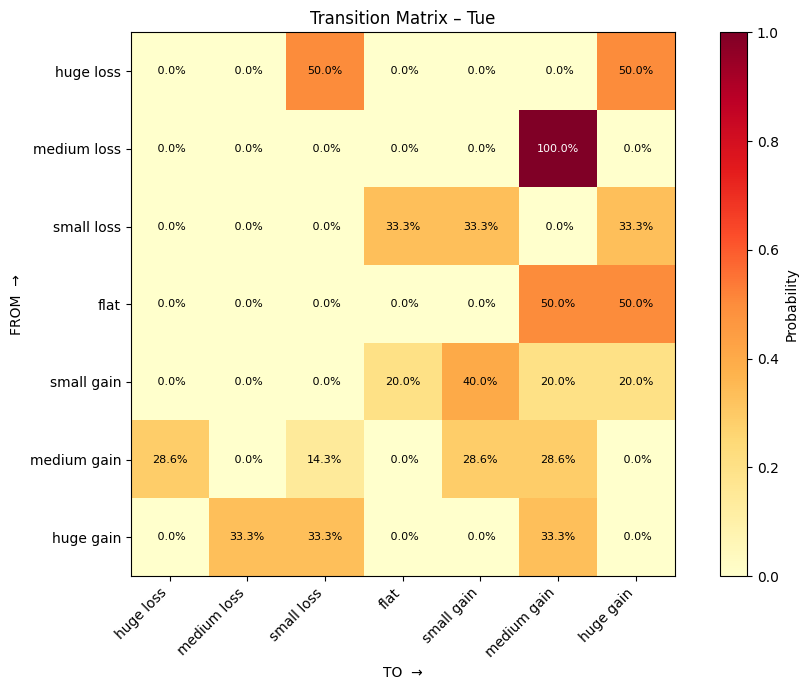

In [132]:
# 1. Build names from your bin edges
names = make_bin_names(bin_edges)

# 2. Pick bucket with top leaderboard edge
bucket = leaderboard_df.index[0]

# 3. Visualise
plot_transition_heat(markov_result, bucket, names)
# How to read it
# Diagonal dominance (bright on the diagonal) ⇒ states persist; trend-following dominates.

# Bright off-diagonal in lower left / upper right ⇒ mean reversion (e.g., gains flip to losses).

# Empty rows/cols (dark) ⇒ states rarely visited ⇒ ignore in signal logic.

# Rule of thumb
# Look for rows whose largest off-diagonal cell exceeds the diagonal cell → those states flip direction more than they persist.

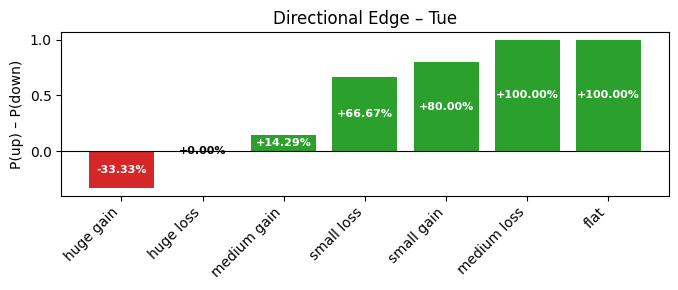

In [133]:
plot_edge_bars(markov_result, bucket, names)
# How to read it
# Green bar = label tends to transition upward next bar.

# Red bar = label tends to transition downward next bar.

# Magnitude = strength of bias (e.g., +0.25 = 25 pp more likely to go up than down).